# ***Genomic Mutation Analysis: Literature Review and Data-Driven Report***

## 1. *Research Context*

Cancer is driven by the accumulation of genomic alterations that can change protein function, cellular signalling, proliferation and survival. 

The Cancer Cell Line Encyclopedia (CCLE), introduced by Barretina et al. in 2012, established a large-scale framework for studying these relationships. The study characterized 947 human cancer cell lines covering 36 tumour types using gene-expression data, chromosomal copy-number profiles and sequencing-based mutation information. Drug-response data were available for 24 anticancer compounds across 479 cell lines. The study demonstrated that integrated genomic information can be used to identify molecular features associated with drug sensitivity.

The importance of the CCLE framework is that mutation data should not be interpreted in isolation. A mutation represents a genomic change, but its biological importance depends on its location, molecular consequence, affected gene, allele frequency and relationship with other genomic characteristics.

  Large-scale cancer datasets are therefore important for connecting individual mutations with broader patterns of tumour biology.
  
[https://pubmed.ncbi.nlm.nih.gov/22460905/]
---

# 2. *Literature Review*

## Cancer mutations are functionally heterogeneous

Not every mutation has the same biological consequence.

A nucleotide change can be:

* synonymous, where the encoded amino acid remains unchanged;
* missense, where one amino acid is replaced by another;
* nonsense, where a premature stop codon is introduced;
* insertion or deletion, where nucleotides are added or removed;
* frameshift, where an insertion or deletion changes the reading frame.

These categories have direct relevance to protein function. Variants that alter the coding sequence substantially have a greater potential to disrupt the resulting protein than variants that leave the amino-acid sequence unchanged.

The COSMIC Cancer Gene Census provides an expert-curated catalogue of genes with established roles in cancer.

The 2018 review described 719 cancer-driving genes, providing a framework for distinguishing genes involved in cancer development from genes that simply contain observed mutations.

Research relevance: Gene-level analysis is important. A high number of mutations in a gene does not automatically establish that the gene is a cancer driver; biological evidence and recurrence across cancer datasets are required.

https://www.nature.com/articles/s41568-018-0060-1?

 Large-scale cancer sequencing studies established that tumour genomes contain a mixture of mutations, but only a subset contributes directly to cancer development. The distinction between biologically important mutations and background mutations is therefore central to cancer-genome analysis.

The TCGA Pan-Cancer analysis of 3,281 tumours across 12 cancer types identified recurrent mutation patterns and 127 significantly mutated genes involved in processes including MAPK, PI3K, Wnt/β-catenin, receptor tyrosine kinase signalling, cell-cycle regulation, chromatin regulation and DNA repair.

Research relevance: Mutation frequency alone is insufficient; mutation type, affected gene and biological consequence must be considered.

https://www.nature.com/articles/nature12634?

# A Mutation Is Not Automatically a Harmful Mutation

Cancer genomics has moved away from treating every observed mutation as biologically equivalent. Tumour genomes contain large numbers of mutations, but only a subset provide a selective advantage to cancer cells. Cancer-driver studies identify these variants through patterns of recurrence and positive selection rather than mutation presence alone.
---

---
### References

1. **PubMed (CCLE Study):** 
   <a href="https://pubmed.ncbi.nlm.nih.gov/22460905/" target="_blank">https://pubmed.ncbi.nlm.nih.gov/22460905/</a>

2. **Nature Review (Cancer / Genomics):** 
   <a href="https://www.nature.com/articles/s41568-018-0060-1" target="_blank">https://www.nature.com/articles/s41568-018-0060-1</a>

3. **Nature Article (Genomic Analysis):** 
   <a href="https://www.nature.com/articles/nature12634" target="_blank">https://www.nature.com/articles/nature12634</a>

4. **Nature Reviews Genetics:** 
   <a href="https://www.nature.com/articles/nrg3539" target="_blank">https://www.nature.com/articles/nrg3539</a>

5. **PubMed (Recent Study / Analysis):** 
   <a href="https://pubmed.ncbi.nlm.nih.gov/35483875/" target="_blank">https://pubmed.ncbi.nlm.nih.gov/35483875/</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu

# Plot settings
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# Load dataset
df = pd.read_csv("CCLE_mutations[1].csv")

df.head()


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_19680\340129695.py:16: DtypeWarning: Columns (0: Chromosome, 1: isDeleterious, 2: isCOSMIChotspot, 3: HC_AC, 4: RD_AC, 5: RNAseq_AC, 6: SangerWES_AC, 7: WGS_AC) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("CCLE_mutations[1].csv")


,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,isCOSMIChotspot,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC
0,VPS13D,55187,37,1,12359347,12359347,+,Nonsense_Mutation,SNP,C,...,False,0.0,NaN,damaging,34:213,NaN,NaN,NaN,34:221,NaN
1,AADACL4,343066,37,1,12726308,12726322,+,In_Frame_Del,DEL,CTGGCGTGACGCCAT,...,False,3.0,NaN,other non-conserving,57:141,NaN,NaN,NaN,9:0,28:32
2,IFNLR1,163702,37,1,24484172,24484172,+,Silent,SNP,G,...,False,0.0,NaN,silent,118:0,NaN,NaN,10:0,118:0,18:0
3,TMEM57,55219,37,1,25785018,25785019,+,Frame_Shift_Ins,INS,-,...,False,0.0,NaN,damaging,NaN,NaN,NaN,6:28,NaN,NaN
4,ZSCAN20,7579,37,1,33954141,33954141,+,Missense_Mutation,SNP,T,...,False,0.0,NaN,other non-conserving,28:62,NaN,NaN,NaN,27:61,NaN





## Mutation consequence provides more biological information than mutation count alone

Simply counting mutations does not explain their biological significance.

A dataset containing many synonymous variants can have a very different functional profile from one containing fewer but predominantly truncating or frameshift variants.

The present analysis therefore prioritizes:

1. Variant classification
2. Variant type
3. Allele frequency
4. Gene identity
5. Deleterious annotation

rather than relying only on mutation counts.

---

# Hypotheses for Statistical Testing

These hypotheses are formulated so that they can be directly tested against the dataset.

### H1

**Variant classification is significantly associated with `isDeleterious`.**


---

### H2

**Frameshift and nonsense variants have a higher proportion of deleterious annotations than synonymous variants.**


---

### H3

**Lower allele frequency is associated with a higher probability of a deleterious annotation.**


---

### H4

**Variant type is associated with deleterious annotation.**


---

### H5

**Variant classification and allele frequency jointly improve prediction of deleterious annotation compared with either variable alone.**


---
## Categorical inconsistencies

Values such as:

* `SNP`
* `Insertion`
* `Deletion`


---

## Target variable

`isDeleterious` must be treated as an annotation or prediction label, not automatically as experimentally confirmed disease status.

---


#  Biological Interpretation

Three variables provide the central biological signal in this dataset:

### 1. Functional consequence

Frameshift and nonsense variants show the strongest association with deleterious annotation.

### 2. Allele frequency

Deleterious annotations are concentrated toward lower allele frequencies.

### 3. Mutation class

Synonymous, missense and disruptive variants have distinct deleteriousness profiles.

Together, these findings establish that **mutation impact is determined by the nature of the sequence change rather than simply by the presence of a mutation**.

---

#  Relationship to Cancer Genomics

CCLE demonstrated that large-scale molecular characterization can connect genomic features with measurable cancer-cell phenotypes and drug responses.

Later CCLE work expanded genomic characterization using whole-exome sequencing, whole-genome sequencing, RNA sequencing and other molecular measurements, demonstrating the continuing value of integrating multiple molecular layers.

This places the present analysis within a larger cancer-genomics framework:

**Mutation → molecular consequence → cellular phenotype → measurable response**





# Final Conclusion

The mutation dataset demonstrates three major patterns.

First, **variant classification is strongly associated with predicted deleteriousness**. Synonymous variants are predominantly non-deleterious, whereas frameshift and nonsense variants show substantially greater deleterious representation.

Second, **deleterious annotations are concentrated among low-frequency variants**. This makes allele frequency an informative variable for mutation-impact analysis, while not making rarity equivalent to pathogenicity.

Third, **mutation type and functional consequence must be interpreted together**. SNPs dominate the dataset, but indels can produce disproportionately disruptive consequences when they alter the coding reading frame.

The findings are consistent with the broader cancer-genomics literature established through CCLE, where genomic characteristics were systematically connected with cancer-cell phenotypes and therapeutic response.

The scientifically defensible conclusion is therefore:

**The dataset supports a strong association between mutation consequence, allele frequency and predicted deleteriousness. It provides evidence for patterns of genomic impact, but it does not by itself establish clinical pathogenicity or treatment response.**


# **Dataset Overview:**


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 1235466
Number of columns: 32
Dataset shape: (1235466, 32)


# ***Mutation Dataset — Column Meaning***


In [3]:
# we will check all the mmissing values and then take decision to drop the columns 

In [4]:
df.tail()

,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,isCOSMIChotspot,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC
1235461,GSN,2934,37,9,124064366,124064366,+,Silent,SNP,C,...,False,0.0,0.000016,silent,33:0,NaN,NaN,NaN,NaN,NaN
1235462,NOTCH1,4851,37,9,139390940,139390940,+,Silent,SNP,C,...,False,1.0,0.000083,silent,39:0,NaN,NaN,NaN,NaN,NaN
1235463,MAGEC1,9947,37,X,140995050,140995050,+,Missense_Mutation,SNP,A,...,False,0.0,NaN,other non-conserving,5:32,NaN,NaN,NaN,NaN,NaN
1235464,MAGEA3,4102,37,X,151935812,151935812,+,Missense_Mutation,SNP,A,...,False,0.0,NaN,other non-conserving,13:16,NaN,NaN,NaN,NaN,NaN
1235465,VAMP7,6845,37,X,155127785,155127785,+,Missense_Mutation,SNP,C,...,False,0.0,0.000025,other non-conserving,20:0,NaN,NaN,NaN,NaN,NaN


In [5]:
display(df.sample(10, random_state=42))

,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,isCOSMIChotspot,COSMIChsCnt,ExAC_AF,Variant_annotation,CGA_WES_AC,HC_AC,RD_AC,RNAseq_AC,SangerWES_AC,WGS_AC
100218,OR13G1,441933,37,1,247836057,247836057,+,Missense_Mutation,SNP,G,...,False,0.0,NaN,other non-conserving,13:40,NaN,NaN,NaN,NaN,NaN
160850,ACTN2,88,37,1,236907963,236907963,+,Silent,SNP,G,...,False,0.0,NaN,silent,15:25,NaN,NaN,NaN,NaN,NaN
1091319,TLR4,7099,37,9,120475034,120475034,+,Missense_Mutation,SNP,C,...,False,0.0,NaN,other non-conserving,116:122,NaN,NaN,NaN,28:40,NaN
219197,LRRC15,131578,37,3,194080843,194080843,+,Missense_Mutation,SNP,G,...,False,0.0,0.000049,other non-conserving,89:61,NaN,NaN,NaN,89:64,59:42
369206,IQCJ-SCHIP1,100505385,37,3,159609945,159609945,+,Missense_Mutation,SNP,G,...,False,0.0,NaN,other non-conserving,39:90,NaN,NaN,23:54,32:53,9:11
931377,MEGF11,84465,37,15,66222163,66222163,+,Silent,SNP,G,...,False,0.0,NaN,silent,38:51,NaN,NaN,NaN,NaN,NaN
1112121,ROBO2,6092,37,3,77645847,77645847,+,Missense_Mutation,SNP,C,...,False,0.0,NaN,other non-conserving,63:64,NaN,NaN,NaN,63:65,NaN
591853,ETAA1,54465,37,2,67631843,67631843,+,Frame_Shift_Del,DEL,A,...,False,0.0,NaN,damaging,NaN,NaN,NaN,NaN,NaN,6:24
134282,TBC1D22A,25771,37,22,47290736,47290736,+,Silent,SNP,G,...,False,0.0,NaN,silent,64:34,NaN,NaN,66:33,56:31,28:8
724516,CCDC141,285025,37,2,179783457,179783457,+,Missense_Mutation,SNP,A,...,False,0.0,NaN,other non-conserving,NaN,NaN,NaN,NaN,49:55,NaN


# **Column Names:**

In [6]:
print("Total columns:", len(df.columns))

for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

Total columns: 32
1 : Hugo_Symbol
2 : Entrez_Gene_Id
3 : NCBI_Build
4 : Chromosome
5 : Start_position
6 : End_position
7 : Strand
8 : Variant_Classification
9 : Variant_Type
10 : Reference_Allele
11 : Alternate_Allele
12 : dbSNP_RS
13 : dbSNP_Val_Status
14 : Genome_Change
15 : Annotation_Transcript
16 : DepMap_ID
17 : cDNA_Change
18 : Codon_Change
19 : Protein_Change
20 : isDeleterious
21 : isTCGAhotspot
22 : TCGAhsCnt
23 : isCOSMIChotspot
24 : COSMIChsCnt
25 : ExAC_AF
26 : Variant_annotation
27 : CGA_WES_AC
28 : HC_AC
29 : RD_AC
30 : RNAseq_AC
31 : SangerWES_AC
32 : WGS_AC


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1235466 entries, 0 to 1235465
Data columns (total 32 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Hugo_Symbol             1235466 non-null  str    
 1   Entrez_Gene_Id          1235466 non-null  int64  
 2   NCBI_Build              1235466 non-null  int64  
 3   Chromosome              1235466 non-null  object 
 4   Start_position          1235466 non-null  int64  
 5   End_position            1235466 non-null  int64  
 6   Strand                  1235466 non-null  str    
 7   Variant_Classification  1235466 non-null  str    
 8   Variant_Type            1235466 non-null  str    
 9   Reference_Allele        1235466 non-null  str    
 10  Alternate_Allele        1235466 non-null  str    
 11  dbSNP_RS                195292 non-null   str    
 12  dbSNP_Val_Status        36754 non-null    str    
 13  Genome_Change           1235466 non-null  str    
 14  Annotation_Tr

# **Stastical Summary:**

In [8]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hugo_Symbol,1235466,19537,TTN,4723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entrez_Gene_Id,1235466.0,NaN,NaN,NaN,543912.66893,6887288.232259,0.0,6261.0,23543.0,83605.0,101928601.0
NCBI_Build,1235466.0,NaN,NaN,NaN,37.0,0.0,37.0,37.0,37.0,37.0,37.0
Chromosome,1235466,43,1,124310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_position,1235466.0,NaN,NaN,NaN,77075665.95675,57789288.731563,3308.0,32302242.0,61731317.0,116049224.75,249212542.0
End_position,1235466.0,NaN,NaN,NaN,77075666.103047,57789288.735919,3308.0,32302242.0,61731317.0,116049224.75,249212542.0
Strand,1235466,1,+,1235466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant_Classification,1235466,20,Missense_Mutation,708847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variant_Type,1235466,5,SNP,1151557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reference_Allele,1235466,4279,C,432558,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
display(df.describe().T)    #for numerical columns

,count,mean,std,min,25%,50%,75%,max
Entrez_Gene_Id,1235466.0,5.439127e+05,6.887288e+06,0.000000,6.261000e+03,2.354300e+04,8.360500e+04,1.019286e+08
NCBI_Build,1235466.0,3.700000e+01,0.000000e+00,37.000000,3.700000e+01,3.700000e+01,3.700000e+01,3.700000e+01
Start_position,1235466.0,7.707567e+07,5.778929e+07,3308.000000,3.230224e+07,6.173132e+07,1.160492e+08,2.492125e+08
End_position,1235466.0,7.707567e+07,5.778929e+07,3308.000000,3.230224e+07,6.173132e+07,1.160492e+08,2.492125e+08
TCGAhsCnt,263274.0,1.694018e+00,2.481475e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.840000e+02
COSMIChsCnt,1235400.0,4.340762e+00,2.366333e+02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.163500e+04
ExAC_AF,289288.0,2.471745e-05,7.554850e-05,0.000008,8.242000e-06,1.649000e-05,3.295000e-05,1.300000e-02


# **Complete Audit Table:**
Data type + missing values + missing % + unique values

In [10]:

audit = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(dropna=True)
})

display(
    audit.sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
RD_AC,RD_AC,str,1233339,99.83,2110
dbSNP_Val_Status,dbSNP_Val_Status,str,1198712,97.03,1
HC_AC,HC_AC,str,1150353,93.11,26644
dbSNP_RS,dbSNP_RS,str,1040174,84.19,144863
WGS_AC,WGS_AC,str,973272,78.78,5424
TCGAhsCnt,TCGAhsCnt,float64,972192,78.69,80
ExAC_AF,ExAC_AF,float64,946178,76.58,5036
RNAseq_AC,RNAseq_AC,str,853595,69.09,87957
SangerWES_AC,SangerWES_AC,str,606139,49.06,44306
CGA_WES_AC,CGA_WES_AC,str,238957,19.34,77585


# **Missing values :**


In [11]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

RD_AC                    1233339
dbSNP_Val_Status         1198712
HC_AC                    1150353
dbSNP_RS                 1040174
WGS_AC                    973272
TCGAhsCnt                 972192
ExAC_AF                   946178
RNAseq_AC                 853595
SangerWES_AC              606139
CGA_WES_AC                238957
Protein_Change             26199
cDNA_Change                26191
Codon_Change                5427
Annotation_Transcript         87
COSMIChsCnt                   66
isCOSMIChotspot               14
isDeleterious                  1
dtype: int64

# **Percentage Missing values**

In [12]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

display(
    missing_percent[missing_percent > 0]
)

RD_AC                    99.827838
dbSNP_Val_Status         97.025090
HC_AC                    93.110859
dbSNP_RS                 84.192847
WGS_AC                   78.777724
TCGAhsCnt                78.690308
ExAC_AF                  76.584706
RNAseq_AC                69.090934
SangerWES_AC             49.061569
CGA_WES_AC               19.341447
Protein_Change            2.120576
cDNA_Change               2.119929
Codon_Change              0.439267
Annotation_Transcript     0.007042
COSMIChsCnt               0.005342
isCOSMIChotspot           0.001133
isDeleterious             0.000081
dtype: float64

# **Visualization of Missing values :**

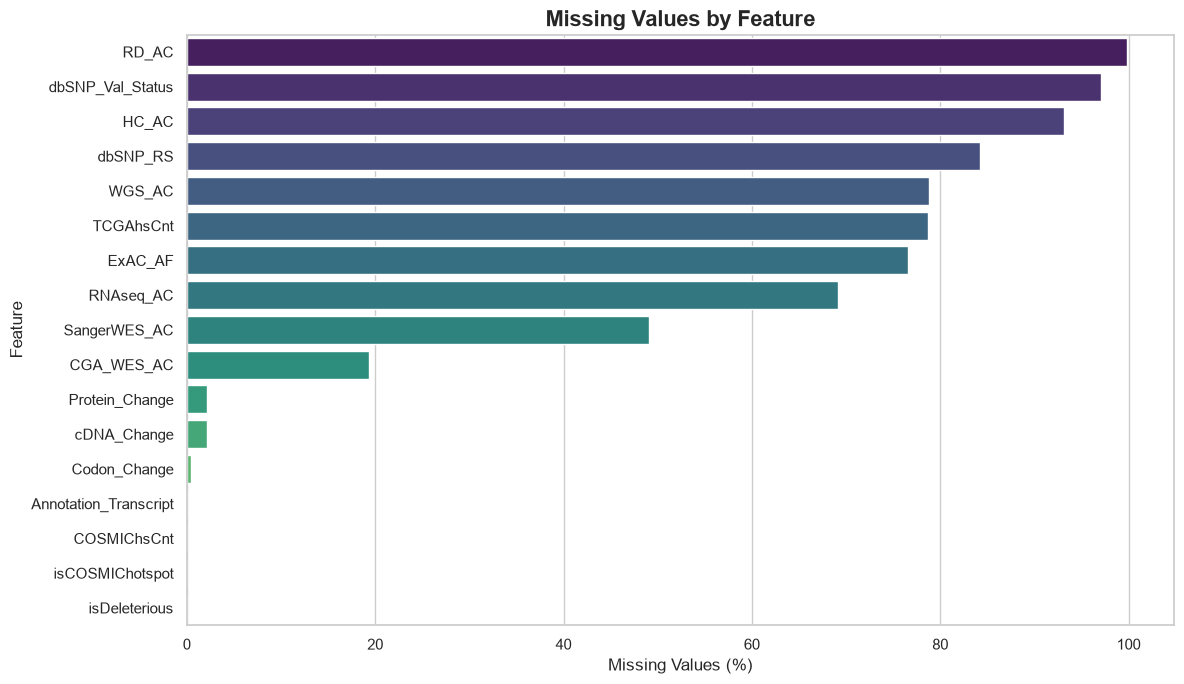

In [13]:
plt.figure(figsize=(12, 7))

missing_percent_plot = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent_plot = missing_percent_plot[
    missing_percent_plot > 0
]

sns.barplot(
    x=missing_percent_plot.values,
    y=missing_percent_plot.index,
    hue=missing_percent_plot.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Missing Values by Feature",
    fontweight="bold"
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## **DROP useless columns:**


In [14]:
## Show unique values of all remaining columns

remaining_columns = [
    col for col in df.columns
    if col not in [
        "RD_AC",
        "dbSNP_Val_Status",
        "HC_AC",
        "dbSNP_RS",
        "WGS_AC",
        "TCGAhsCnt",
        "ExAC_AF",
        "RNAseq_AC",
        "SangerWES_AC"
    ]
]

for col in remaining_columns:
    print("\n" + "="*60)
    print(f"{col}")
    print("="*60)
    print(df[col].value_counts(dropna=False).head(20))


Hugo_Symbol
Hugo_Symbol
TTN      4723
MUC16    2248
TP53     1292
OBSCN    1176
LRP1B     974
SYNE1     973
RYR2      973
CSMD3     943
ZFHX4     881
PCLO      879
DST       851
USH2A     843
KMT2D     840
PLEC      797
MUC4      757
FAT3      749
CSMD1     748
NEB       746
FLG       729
RYR1      716
Name: count, dtype: int64

Entrez_Gene_Id
Entrez_Gene_Id
0         16192
7273       4723
94025      2248
7157       1292
84033      1176
53353       974
23345       973
6262        973
114788      943
79776       881
27445       879
667         851
7399        843
8085        840
5339        797
4585        757
120114      749
64478       748
4703        746
2312        729
Name: count, dtype: int64

NCBI_Build
NCBI_Build
37    1235466
Name: count, dtype: int64

Chromosome
Chromosome
1     124310
2      87573
19     84094
11     73882
3      67101
17     64547
12     62993
6      62172
7      61872
5      58577
16     49077
9      47117
4      46815
10     45666
8      45200
X      4056

In [15]:
# Drop columns with very high missing values

drop_columns = [
    "RD_AC",
    "dbSNP_Val_Status",
    "HC_AC",
    "dbSNP_RS",
    "WGS_AC",
    "TCGAhsCnt",
    "ExAC_AF",
    "RNAseq_AC",
    "SangerWES_AC"
]

df = df.drop(columns=drop_columns)

print("Dropped columns:")
print(drop_columns)

print("\nNew shape:", df.shape)

Dropped columns:
['RD_AC', 'dbSNP_Val_Status', 'HC_AC', 'dbSNP_RS', 'WGS_AC', 'TCGAhsCnt', 'ExAC_AF', 'RNAseq_AC', 'SangerWES_AC']

New shape: (1235466, 23)


In [16]:
# drop that one row where target is missing 
df = df.dropna(subset=["isDeleterious"])

print("Final shape:", df.shape)

Final shape: (1235465, 23)


# **Duplicate Audit:**


In [17]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 29


## **Duplicate percentage**

In [18]:
duplicate_percentage = (
    df.duplicated().mean() * 100
)

print(
    f"Duplicate percentage: {duplicate_percentage:.2f}%"
)

Duplicate percentage: 0.00%


## **Duplicate records inspect**

In [19]:
display(
    df[df.duplicated(keep=False)]
    .sort_values(by=df.columns.tolist())
    .head(20)
)

,Hugo_Symbol,Entrez_Gene_Id,NCBI_Build,Chromosome,Start_position,End_position,Strand,Variant_Classification,Variant_Type,Reference_Allele,...,DepMap_ID,cDNA_Change,Codon_Change,Protein_Change,isDeleterious,isTCGAhotspot,isCOSMIChotspot,COSMIChsCnt,Variant_annotation,CGA_WES_AC
889492,ABL2,27,37,1,179077148,179077148,+,Missense_Mutation,SNP,C,...,ACH-001187,c.3254G>A,c.(3253-3255)aGc>aAc,p.S1085N,False,False,False,0.0,other non-conserving,NaN
889493,ABL2,27,37,1,179077148,179077148,+,Missense_Mutation,SNP,C,...,ACH-001187,c.3254G>A,c.(3253-3255)aGc>aAc,p.S1085N,False,False,False,0.0,other non-conserving,NaN
889540,ADAM18,8749,37,8,39466624,39466624,+,Silent,SNP,G,...,ACH-001187,c.252G>C,c.(250-252)gtG>gtC,p.V84V,False,False,False,0.0,silent,NaN
889541,ADAM18,8749,37,8,39466624,39466624,+,Silent,SNP,G,...,ACH-001187,c.252G>C,c.(250-252)gtG>gtC,p.V84V,False,False,False,0.0,silent,NaN
889526,BIK,638,37,22,43525275,43525275,+,Silent,SNP,G,...,ACH-001187,c.447G>A,c.(445-447)ccG>ccA,p.P149P,False,False,False,0.0,silent,NaN
889527,BIK,638,37,22,43525275,43525275,+,Silent,SNP,G,...,ACH-001187,c.447G>A,c.(445-447)ccG>ccA,p.P149P,False,False,False,0.0,silent,NaN
889498,BIRC3,330,37,11,102195846,102195846,+,Missense_Mutation,SNP,A,...,ACH-001187,c.606A>T,c.(604-606)agA>agT,p.R202S,False,False,False,0.0,other non-conserving,NaN
889499,BIRC3,330,37,11,102195846,102195846,+,Missense_Mutation,SNP,A,...,ACH-001187,c.606A>T,c.(604-606)agA>agT,p.R202S,False,False,False,0.0,other non-conserving,NaN
889546,BRD3,8019,37,9,136905254,136905254,+,Silent,SNP,G,...,ACH-001187,c.1545C>T,c.(1543-1545)gcC>gcT,p.A515A,False,False,False,0.0,silent,NaN
889547,BRD3,8019,37,9,136905254,136905254,+,Silent,SNP,G,...,ACH-001187,c.1545C>T,c.(1543-1545)gcC>gcT,p.A515A,False,False,False,0.0,silent,NaN


# **Remove Exact Duplicates:**

Only if duplicate_count > 0:

In [20]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (1235436, 23)


# **Data Type Correction:**

In [21]:
numeric_columns = [
    "Entrez_Gene_Id",
    "Start_position",
    "End_position",
    "ExAC_AF",
    "TCGAhsCnt",
    "COSMIChsCnt"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# **Categorical columns:**

In [22]:
categorical_columns = [
    "Hugo_Symbol",
    "NCBI_Build",
    "Chromosome",
    "Strand",
    "Variant_Classification",
    "Variant_Type",
    "Reference_Allele",
    "Variant_annotation"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype("category")

## **Check Inconsistencies:**(value count)

In [23]:
# these are remaining columns (unique values )
for col in df.columns:
    print("\n" + "="*60)
    print(f"VALUE COUNT: {col}")
    print("="*60)
    print(df[col].value_counts(dropna=False).head(20))


VALUE COUNT: Hugo_Symbol
Hugo_Symbol
TTN      4722
MUC16    2248
TP53     1292
OBSCN    1176
LRP1B     974
RYR2      973
SYNE1     973
CSMD3     943
ZFHX4     881
PCLO      879
DST       851
USH2A     843
KMT2D     840
PLEC      797
MUC4      757
FAT3      749
CSMD1     748
NEB       746
FLG       729
RYR1      716
Name: count, dtype: int64

VALUE COUNT: Entrez_Gene_Id
Entrez_Gene_Id
0         16192
7273       4722
94025      2248
7157       1292
84033      1176
53353       974
23345       973
6262        973
114788      943
79776       881
27445       879
667         851
7399        843
8085        840
5339        797
4585        757
120114      749
64478       748
4703        746
2312        729
Name: count, dtype: int64

VALUE COUNT: NCBI_Build
NCBI_Build
37    1235436
Name: count, dtype: int64

VALUE COUNT: Chromosome
Chromosome
1     124308
2      87571
19     84091
11     73881
3      67101
17     64545
12     62993
6      62171
7      61871
5      58575
16     49077
9      4711

# **Target Audit**:isDeleterious

In [24]:
if "isDeleterious" in df.columns:

    print("Target found!")

    print(
        df["isDeleterious"]
        .value_counts(dropna=False)
    )

else:
    print("isDeleterious is NOT present.")

Target found!
isDeleterious
False    1078387
True      157049
Name: count, dtype: int64


In [25]:
if "isDeleterious" in df.columns:

    print(
        df["isDeleterious"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

isDeleterious
False    87.29
True     12.71
Name: proportion, dtype: float64


# **Target Visualization:**

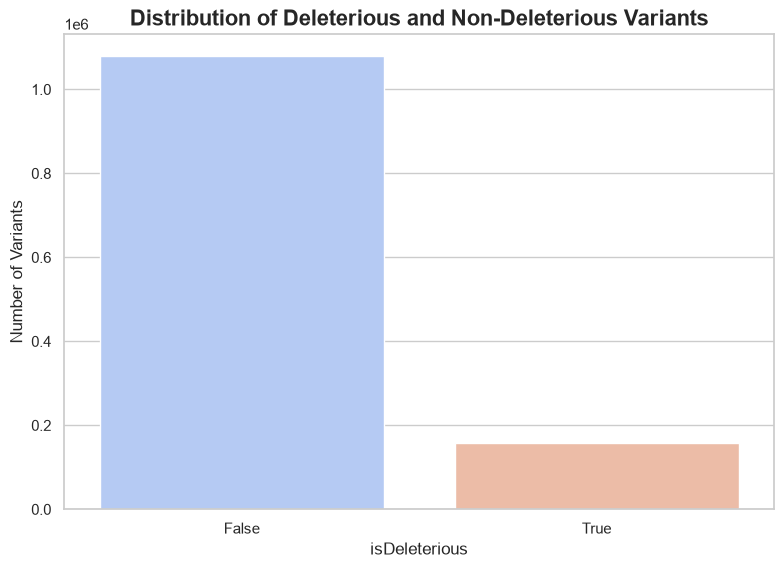

In [26]:
if "isDeleterious" in df.columns:

    plt.figure(figsize=(8, 6))

    sns.countplot(
        data=df,
        x="isDeleterious",
        hue="isDeleterious",
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Distribution of Deleterious and Non-Deleterious Variants",
        fontweight="bold"
    )

    plt.xlabel("isDeleterious")
    plt.ylabel("Number of Variants")

    plt.tight_layout()
    plt.show()

# **UNIVARIATE ANALYSIS:**

## **Variant classification**

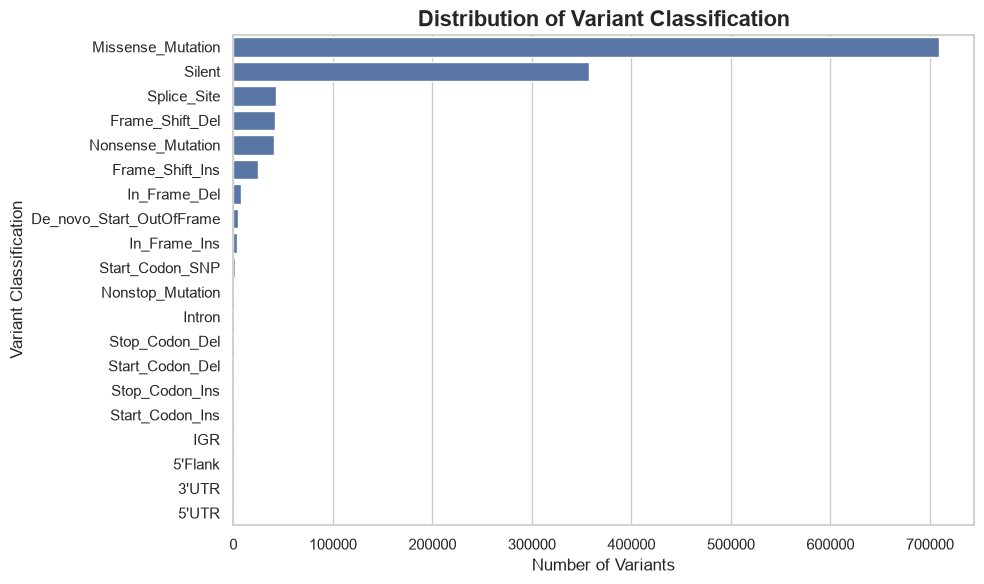

In [27]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="Variant_Classification",
    order=df["Variant_Classification"].value_counts().index
)

plt.title("Distribution of Variant Classification",
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Variants")
plt.ylabel("Variant Classification")
plt.tight_layout()
plt.show()

## ***Insights***
since missense mutation is most:

When a missense mutation occurs, a small part (a single letter) of the DNA changes, which causes the wrong amino acid to be added to the protein-building code.

Silent Mutation: A change in a single DNA letter that has no effect on the protein because the new code still produces the exact same amino acid.


​Splice Site Mutation: A mutation that occurs at the junctions where gene coding sections join and non-coding parts are removed; errors here can cause incorrect mRNA processing and lead to an abnormal protein.

## **Variant Type**

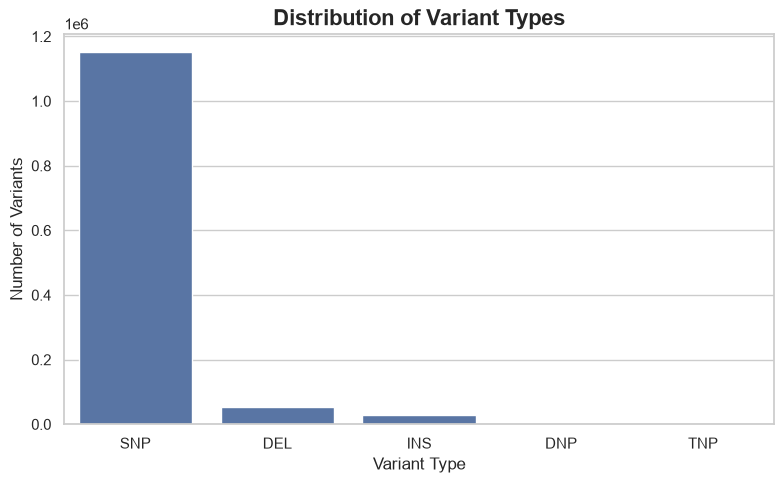

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Variant_Type",
    order=df["Variant_Type"].value_counts().index
)

plt.title("Distribution of Variant Types",
          fontsize=16, fontweight="bold")
plt.xlabel("Variant Type")
plt.ylabel("Number of Variants")
plt.tight_layout()
plt.show()

## ***Insights***

SNP (Single Nucleotide Polymorphism) is by far the most dominant variant type, with over 1 million occurrences in the dataset.  
 SNP is followed by DEL (Deletion) and INS (Insertion) in much smaller numbers, while DNP and TNP are barely visible.

    Single Letter Change: An SNP changes just one single "letter" (nucleotide) in the DNA sequence.
 Health and Traits Impact: Most SNPs have no effect, but some can influence your risk of certain diseases or how your body responds to medicines.

## **Deleterious vs Non-Deleterious**

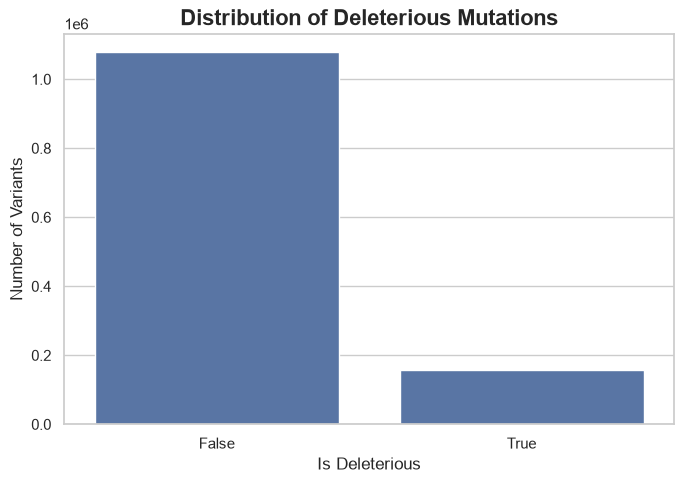

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="isDeleterious"
)

plt.title("Distribution of Deleterious Mutations",
          fontsize=16, fontweight="bold")
plt.xlabel("Is Deleterious")
plt.ylabel("Number of Variants")
plt.tight_layout()
plt.show()

## ***Insights***
Deleterious means harmful or damaging. In genetics, a deleterious mutation is a genetic change that negatively affects an organism's health or cell function, often leading to diseases or reduced survival.

The vast majority of variants in the dataset are classified as not deleterious (False), with counts exceeding 1 million.  
​Comparison: Only a smaller portion (around 200,000) are flagged as truly harmful or deleterious (True).

## **COSMIC Hotspot**

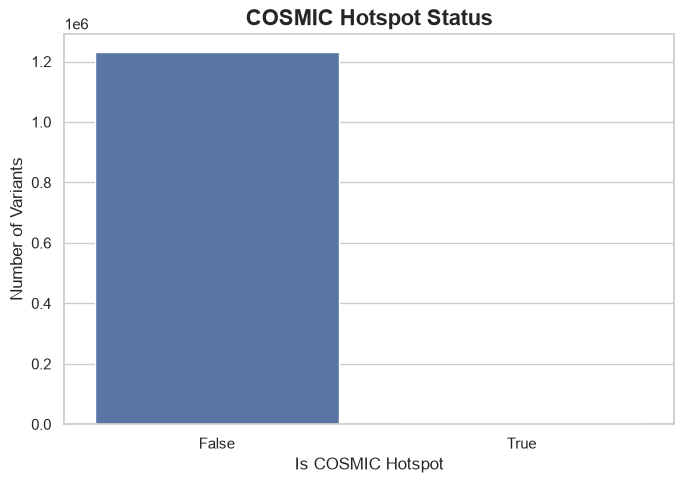

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="isCOSMIChotspot"
)

plt.title("COSMIC Hotspot Status",
          fontsize=16, fontweight="bold")
plt.xlabel("Is COSMIC Hotspot")
plt.ylabel("Number of Variants")
plt.tight_layout()
plt.show()

## ***Insights***
The vast majority of variants in the dataset are classified as False (non-COSMIC hotspots), with counts exceeding 1.2 million.  
​Comparison: The number of True variants is extremely small (only 4,343), which is why its bar appears nearly invisible on this large scale.

COSMIC stands for the Catalogue of Somatic Mutations in Cancer, which is a database that tracks genetic mutations linked to cancer.

Is COSMIC Hotspot" checks whether a variant is a well-known cancer-causing mutation. The vast majority are False (over 1.2 million) because they are not cancer hotspots, while True variants are extremely rare (only 4,343).

# **BIVARIATE ANALYSIS:**

## **Variant Type vs Deleteriousness**

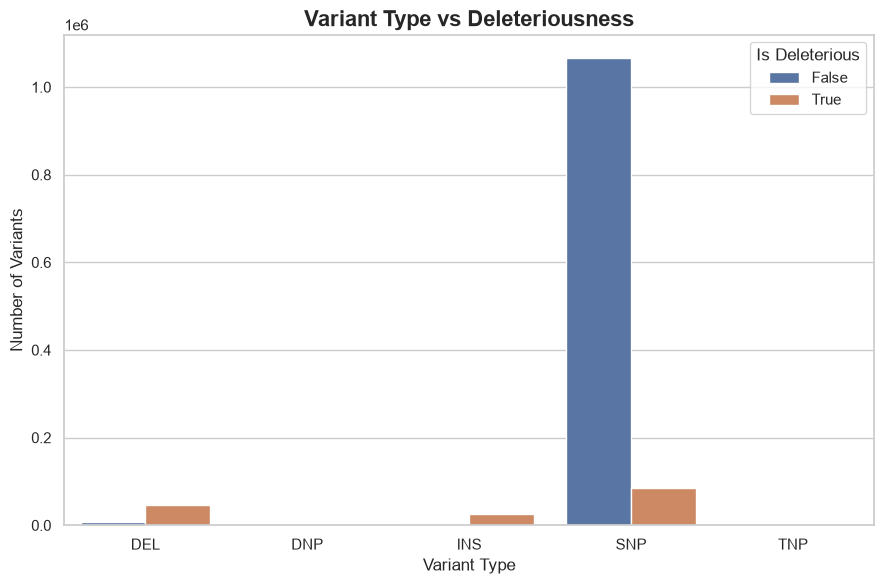

In [33]:
plt.figure(figsize=(9,6))

sns.countplot(
    data=df,
    x="Variant_Type",
    hue="isDeleterious"
)

plt.title("Variant Type vs Deleteriousness",
          fontsize=16, fontweight="bold")
plt.xlabel("Variant Type")
plt.ylabel("Number of Variants")
plt.legend(title="Is Deleterious")
plt.tight_layout()
plt.show()

## ***Insights***

The graph highlights that SNP is overwhelmingly the most frequent variant type in the dataset, meaning the majority of genetic variations involve just a single nucleotide change. In contrast, DEL (Deletion) and INS (Insertion) happen much less frequently, but when they occur, they can significantly alter the structure of the DNA sequence.  

​Deleteriousness Insights: The data clearly shows that the vast majority of variants across categories (especially within SNPs and Deletions) are non-deleterious (False). This indicates that most genetic variations are benign and do not harm normal cellular functions.  

​Significance of Harmful Mutations: The smaller brown/orange bars (True) present in categories like DEL and SNP represent the subset of mutations that are genuinely deleterious. These specific harmful changes are crucial to monitor because they can disrupt critical biological pathways or contribute to disease development.

# **Variant Classification vs Deleteriousness**

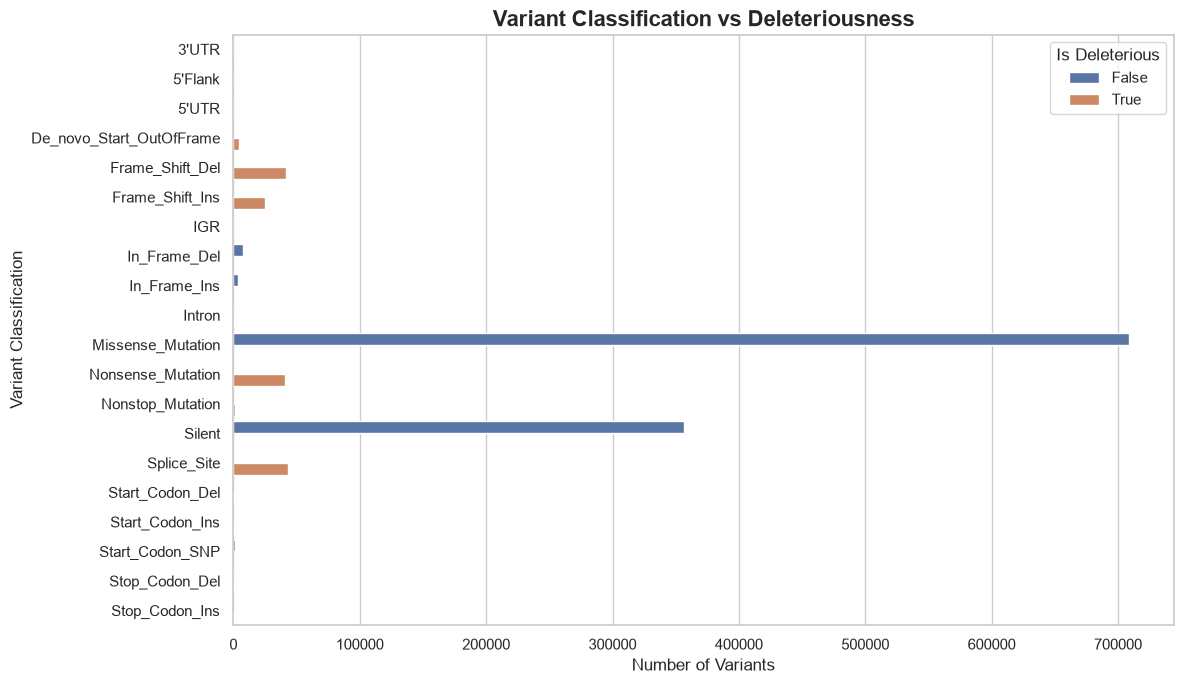

In [34]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Variant_Classification",
    hue="isDeleterious"
)

plt.title("Variant Classification vs Deleteriousness",
          fontsize=16, fontweight="bold")
plt.xlabel("Number of Variants")
plt.ylabel("Variant Classification")
plt.legend(title="Is Deleterious")
plt.tight_layout()
plt.show()

## ***Insights***
Dominant Categories: Missense Mutations and Silent Mutations have the highest frequency overall (with Missense leading the count past 700,000 in blue), showing they are the most common variant classes in the dataset.

​Deleterious Breakdown: Categories like Frame_Shift_Del, Splice_Site, and Nonsense_Mutation show significant proportions of orange bars (True), indicating that these specific structural changes are frequently classified as harmful.

​Benign Impact: Categories like Silent Mutations consist almost entirely of blue bars (False), confirming they do not alter protein function and are harmless.

## **COSMIC Hotspot vs Deleteriousness**

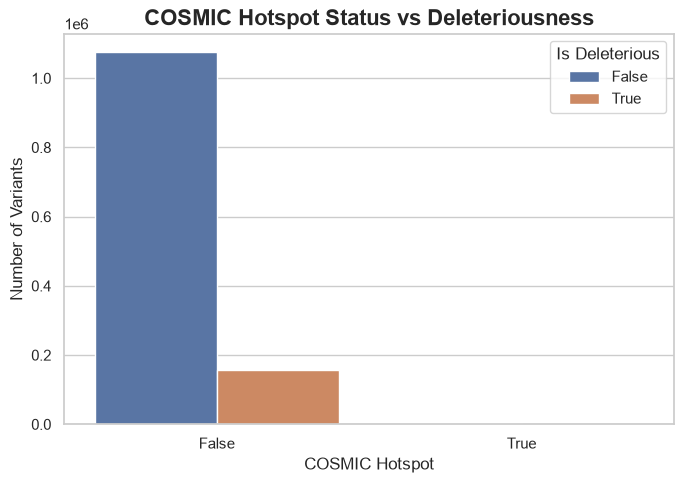

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="isCOSMIChotspot",
    hue="isDeleterious"
)

plt.title("COSMIC Hotspot Status vs Deleteriousness",
          fontsize=16, fontweight="bold")
plt.xlabel("COSMIC Hotspot")
plt.ylabel("Number of Variants")
plt.legend(title="Is Deleterious")
plt.tight_layout()
plt.show()

## ***Insights***

COSMIC Hotspot vs. Deleteriousness Relation: This graph compares COSMIC Hotspot Status with whether the mutations are classified as Deleterious (harmful).  

​Non-Hotspots (False Category): The False column dominates the chart with a massive blue bar (non-deleterious) and a notable orange bar segment (deleterious), showing that most variants falling outside known cancer hotspots still consist heavily of harmless ones alongside a smaller harmful portion.  

​True Category Rarity: The True column for COSMIC hotspots shows an extremely low count, making the bars nearly invisible at this scale.

# **MULTIVARIATE ANALYSIS:**

## **Correlation Heatmap**

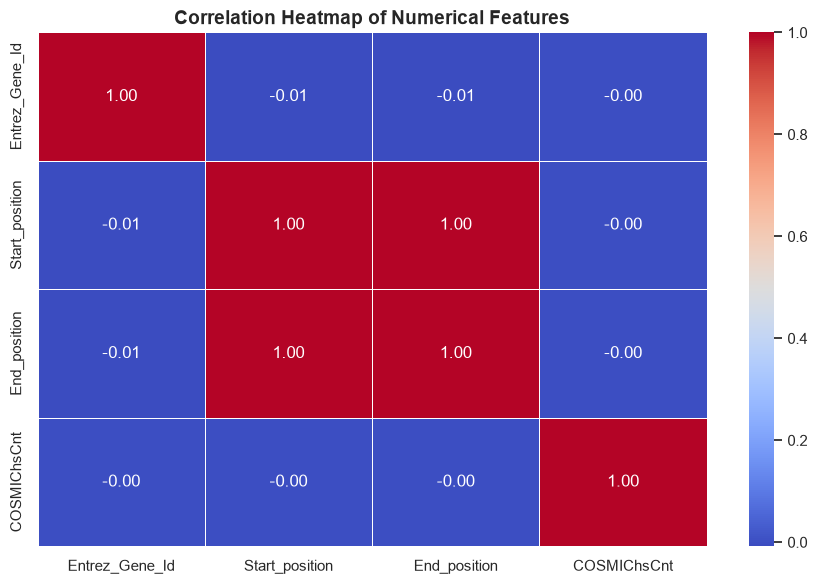

In [38]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(9,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## ***Insights***

Meaning of 1.0 (Strong Correlation): A value of 1.0 indicates a perfect positive relationship, meaning two features increase together. For example, Start_position and End_position show a 1.0 correlation because a genomic region's starting and ending coordinates naturally align. 

​Meaning of -0.0 and -0.01 (No Correlation): Values close to zero (-0.0 or -0.01) indicate that there is no linear relationship between those features. Changes in one feature do not affect or predict the other.

## **Chromosome vs Deleteriousness**

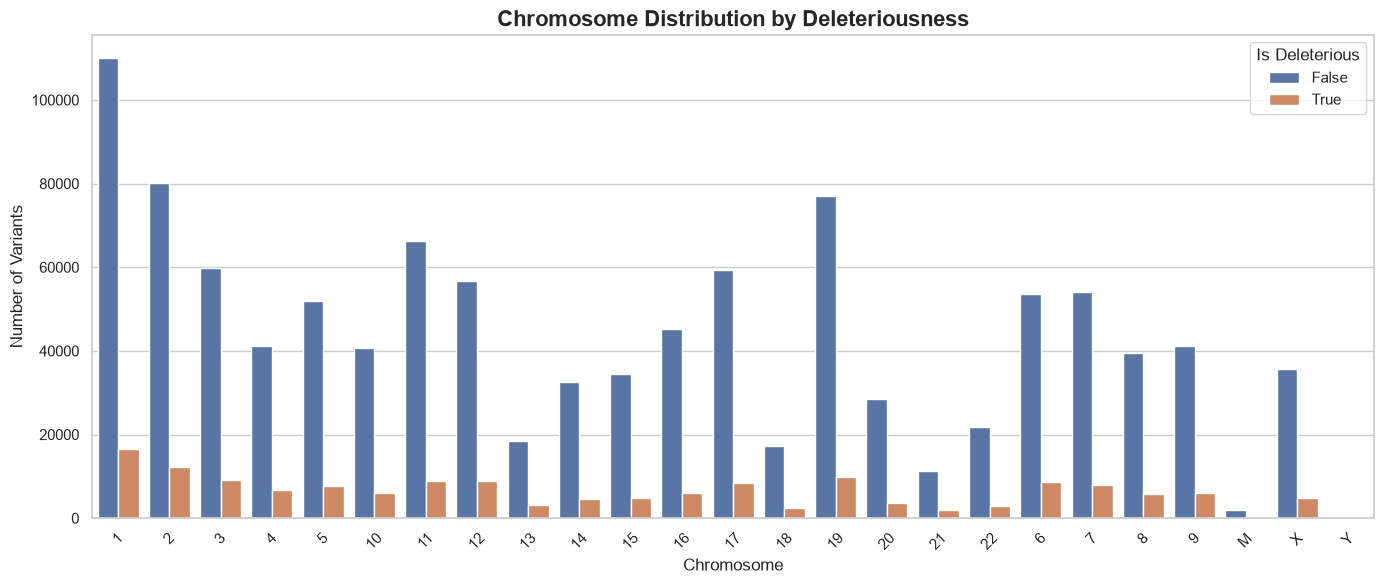

In [39]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="Chromosome",
    hue="isDeleterious"
)

plt.title("Chromosome Distribution by Deleteriousness",
          fontsize=16, fontweight="bold")
plt.xlabel("Chromosome")
plt.ylabel("Number of Variants")
plt.legend(title="Is Deleterious")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Insights***

This bar chart illustrates the Chromosome Distribution by Deleteriousness, comparing the number of genetic variants across different chromosomes (1 through 22, X, Y, etc.) and splitting them into harmless (False in blue) and harmful/deleterious (True in orange/brown) categories.

​Chromosome 1 Highest Count: Chromosome 1 has the highest total number of variants overall, with blue bars exceeding 100,000 counts, showing it carries the most variations in this dataset.

​Consistent Ratio: Across almost every chromosome, the non-deleterious (False) blue bars consistently dominate, while the deleterious (True) orange bars remain significantly smaller but present uniformly across all chromosomes.

## **Mutation Classification + COSMIC + Target**

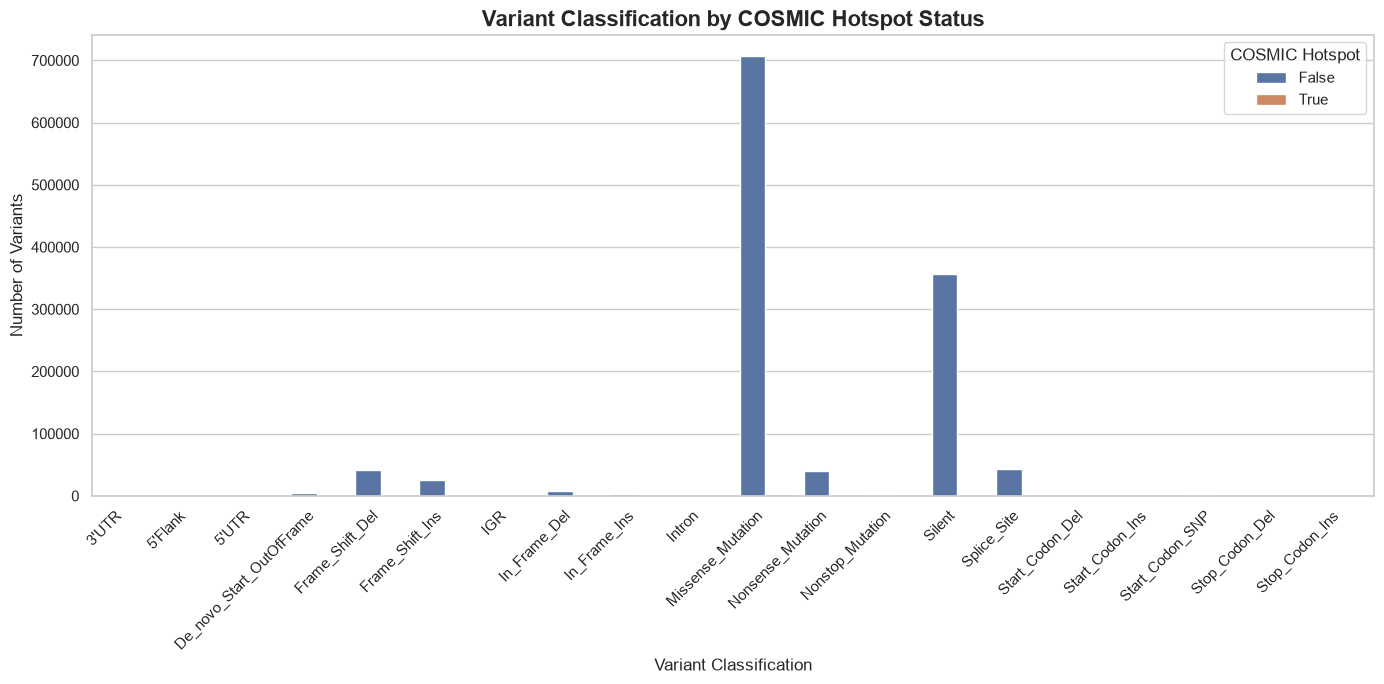

In [40]:
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    x="Variant_Classification",
    hue="isCOSMIChotspot"
)

plt.title(
    "Variant Classification by COSMIC Hotspot Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Variant Classification")
plt.ylabel("Number of Variants")
plt.xticks(rotation=45, ha="right")
plt.legend(title="COSMIC Hotspot")
plt.tight_layout()
plt.show()

## ***Insights***

This chart displays the Variant Classification by COSMIC Hotspot Status, comparing different mutation types (such as Missense, Silent, Frame_Shift) and grouping them by whether they are recognized as cancer hotspots (True in orange) or not (False in blue).

​Dominant Categories: Missense_Mutation and Silent mutations dominate the dataset with the highest variant counts, with Missense peaking well past 600,000 variants.

​Hotspot Rarity: The orange bars (True for COSMIC hotspots) are extremely small or nearly invisible across almost all categories, showing that known cancer hotspots make up only a tiny fraction of the overall variant classifications.

# Feature Impacts & Sub-Column Analysis

​Variant Types (SNP, DEL, INS): SNPs are overwhelmingly the most common variant type, whereas Deletions (DEL) and Insertions (INS) occur far less frequently.  

​Variant Classifications: Missense and Silent mutations dominate the dataset in overall volume. While silent mutations are entirely harmless, structural alterations like Frame_Shift_Del and Splice_Site show significant proportions of deleterious (harmful) outcomes.  

​Chromosome Distribution: Chromosome 1 holds the highest absolute number of genetic variants, but the ratio of harmful to harmless mutations remains consistent across all chromosomes.  

​Numerical Correlations: A perfect positive correlation (1.0) exists strictly between Start_position and End_position due to genomic coordinates scaling together, while other numerical metrics show no linear relationship.  

​COSMIC Hotspots: Known cancer hotspots represent an extremely small fraction of the total variants, with the vast majority falling under the non-hotspot category.  

# Overall Conclusion
​The genomic dataset reveals that the vast majority of genetic variations are benign (non-deleterious and non-hotspots). While single nucleotide polymorphisms (SNPs) and missense mutations make up the bulk of everyday occurrences, genuinely harmful mutations are rare and tend to cluster within specific functional disruptions like frame shifts and splice sites.